# Import librerie e creazione DF

In [22]:
import pandas as pd
import numpy as np
import optuna
import time
import threading
import psutil
import os
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv('dati_tesi_finali_addestramento.csv', sep=',', encoding='UTF-8')

# Preparazione dataset

1. Gestione colonne di data

In [3]:
df["data_record_start_time"] = pd.to_datetime(df["data_record_start_time"])
df['data_record_end_time'] = pd.to_datetime(df['data_record_end_time'])

2. Creazione funzione di analisi tempo, RAM e CPU

In [4]:
_process      = psutil.Process(os.getpid())
LOGICAL_CORES = 8   # 4 core fisici x 2 hyperthreading

class ResourceMonitor:
    """
    Campiona RAM (RSS) e tempo wall-clock durante il fit.
    La CPU viene misurata una volta dopo il fit su un intervallo
    reale di 1s e normalizzata per i logical processor (8),
    cosi il valore e confrontabile con il Task Manager.
    """

    def start(self):
        self._ram_samples = []
        self._cpu_samples = []
        self._t_start     = time.time()
        self._stop        = threading.Event()
        # prima chiamata a cpu_percent per inizializzare il contatore
        _process.cpu_percent()

        def _sampler():
            while not self._stop.is_set():
                self._ram_samples.append(
                    _process.memory_info().rss / 1024 ** 2
                )
                self._cpu_samples.append(
                    _process.cpu_percent() / LOGICAL_CORES
                )
                time.sleep(0.5)

        self._thread = threading.Thread(target=_sampler, daemon=True)
        self._thread.start()
        return self

    def stop(self):
        self._stop.set()
        self._thread.join()
        self.elapsed_s    = time.time() - self._t_start
        self.ram_mean_mb  = float(np.mean(self._ram_samples))
        self.ram_peak_mb  = float(np.max(self._ram_samples))
        self.ram_delta_mb = self.ram_peak_mb - self._ram_samples[0]
        self.cpu_pct      = float(np.mean(self._cpu_samples)) if self._cpu_samples else 0.0
        return self

    def report(self):
        print(f"  Tempo di addestramento + fine tuning          : {self.elapsed_s:.1f}s")
        print(f"  RAM media utilizzata                          : {self.ram_mean_mb:.0f} MB")
        print(f"  CPU utilizzata                                : {self.cpu_pct:.1f}%")

3. Fold dataset

In [19]:
# Fold 1 (test invernale)   — Train: gen–set | Val: ott | Test: nov–dic
# Fold 2 (test estivo)      — Train: gen–apr | Val: mag | Test: giu–lug
# Fold 3 (test primaverile) — Train: gen–feb | Val: mar | Test: apr–mag

FOLDS = [
    {
        "name":          "Fold 1 — test invernale (nov–dic)",
        "cutoff_train":  pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":          "Fold 2 — test estivo (giu–lug)",
        "cutoff_train":  pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":          "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train":  pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-05-31 23:59:59"),
    },
]

4. Feature Engineering

In [6]:
def add_time_features(df):
    t = df["data_record_start_time"]
    df = df.copy()
    df["hour"]       = t.dt.hour
    df["dayofweek"]  = t.dt.dayofweek
    df["day"]        = t.dt.day
    df["month"]      = t.dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["hour_sin"]   = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]    = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"]    = np.cos(2 * np.pi * df["dayofweek"] / 7)
    return df

def add_lag_features(df_train, df_val, df_test):
    full = pd.concat([df_train, df_val, df_test]).sort_values(
        ["station_id", "data_record_start_time"]
    )
    g = ["station_id"]
    full["lag_1h"]       = full.groupby(g)["data_record_value"].shift(1)
    full["lag_2h"]       = full.groupby(g)["data_record_value"].shift(2)
    full["lag_24h"]      = full.groupby(g)["data_record_value"].shift(24)
    full["roll_mean_6h"] = (
        full.groupby(g)["data_record_value"]
            .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    )
    return (full.loc[df_train.index],
            full.loc[df_val.index],
            full.loc[df_test.index])

FEATURES = [
    "station_id", "station_lat", "station_lon", "station_altitude",
    "region_enc",
    "temperature_2m (°C)", "relative_humidity_2m (%)",
    "precipitation (mm)", "wind_speed_10m (km/h)", "wind_direction_10m (°)",
    "hour", "dayofweek", "day", "month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1h", "lag_2h", "lag_24h", "roll_mean_6h",
]

le_region = LabelEncoder()
df["region_enc"] = le_region.fit_transform(df["region_name"].astype(str))
df = add_time_features(df)

# Addestramento XGBoost

In [14]:
N_TRIALS = 30

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            return np.expm1(y)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # ── Optuna ───────────────────────────
        def objective(trial):
            params = {
                "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
                "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth":        trial.suggest_int("max_depth", 3, 8),
                "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": 42, "n_jobs": -1,
                "eval_metric": "rmse", "early_stopping_rounds": 30,
            }
            m = XGBRegressor(**params)
            m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            return mean_squared_error(y_val, m.predict(X_val)) ** 0.5

        # ── Optuna + fit finale con monitoraggio ──
        monitor = ResourceMonitor().start()

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")

        model = XGBRegressor(
            **best,
            random_state=42, n_jobs=-1,
            eval_metric="rmse", early_stopping_rounds=50,
        )

        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        monitor.stop()

        print(f"  Best iteration: {model.best_iteration}")
        monitor.report()

        # ── Metriche ─────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_train, y_train)
        pred_v, true_v = metrics("Val",  X_val,  y_val)
        pred_t, true_t = metrics("Test", X_test, y_test)

        fi   = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")

        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":           fold["name"],
            "pollutant":      pollutant,
            "n_train":        len(X_train),
            "n_val":          len(X_val),
            "n_test":         len(X_test),
            "best_iter":      model.best_iteration,
            "test_mae":       mean_absolute_error(true_t, pred_t),
            "test_rmse":      np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":        r2_score(true_t, pred_t),
            "top3_feat":      top3,
            "train_time_s":   round(monitor.elapsed_s, 1),
            "ram_mean_mb":    round(monitor.ram_mean_mb, 1),
            "cpu_pct":        round(monitor.cpu_pct, 1),
            "best_params":    str(best),
        })

# ─────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold","pollutant","n_train","n_test",
               "test_mae","test_rmse","test_r2",
               "train_time_s","ram_mean_mb","cpu_pct"]].to_string(index=False))

summary.to_csv("XGBoost_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Migliori iperparametri: {'n_estimators': 431, 'learning_rate': 0.08793641207623464, 'max_depth': 8, 'subsample': 0.9401253487586924, 'colsample_bytree': 0.6021796128219522, 'min_child_weight': 8, 'reg_alpha': 0.007865137330185708, 'reg_lambda': 0.019097354910891203}
  Best iteration: 87
  Tempo di addestramento + fine tuning          : 453.6s
  RAM media utilizzata                          : 582 MB
  CPU utilizzata                                : 65.1%
  Train  → MAE=49.915  RMSE=97.192  R²=0.8978
  Val    → MAE=66.802  RMSE=124.305  R²=0.8067
  Test   → MAE=123.014  RMSE=210.720  R²=0.6952
  Top f

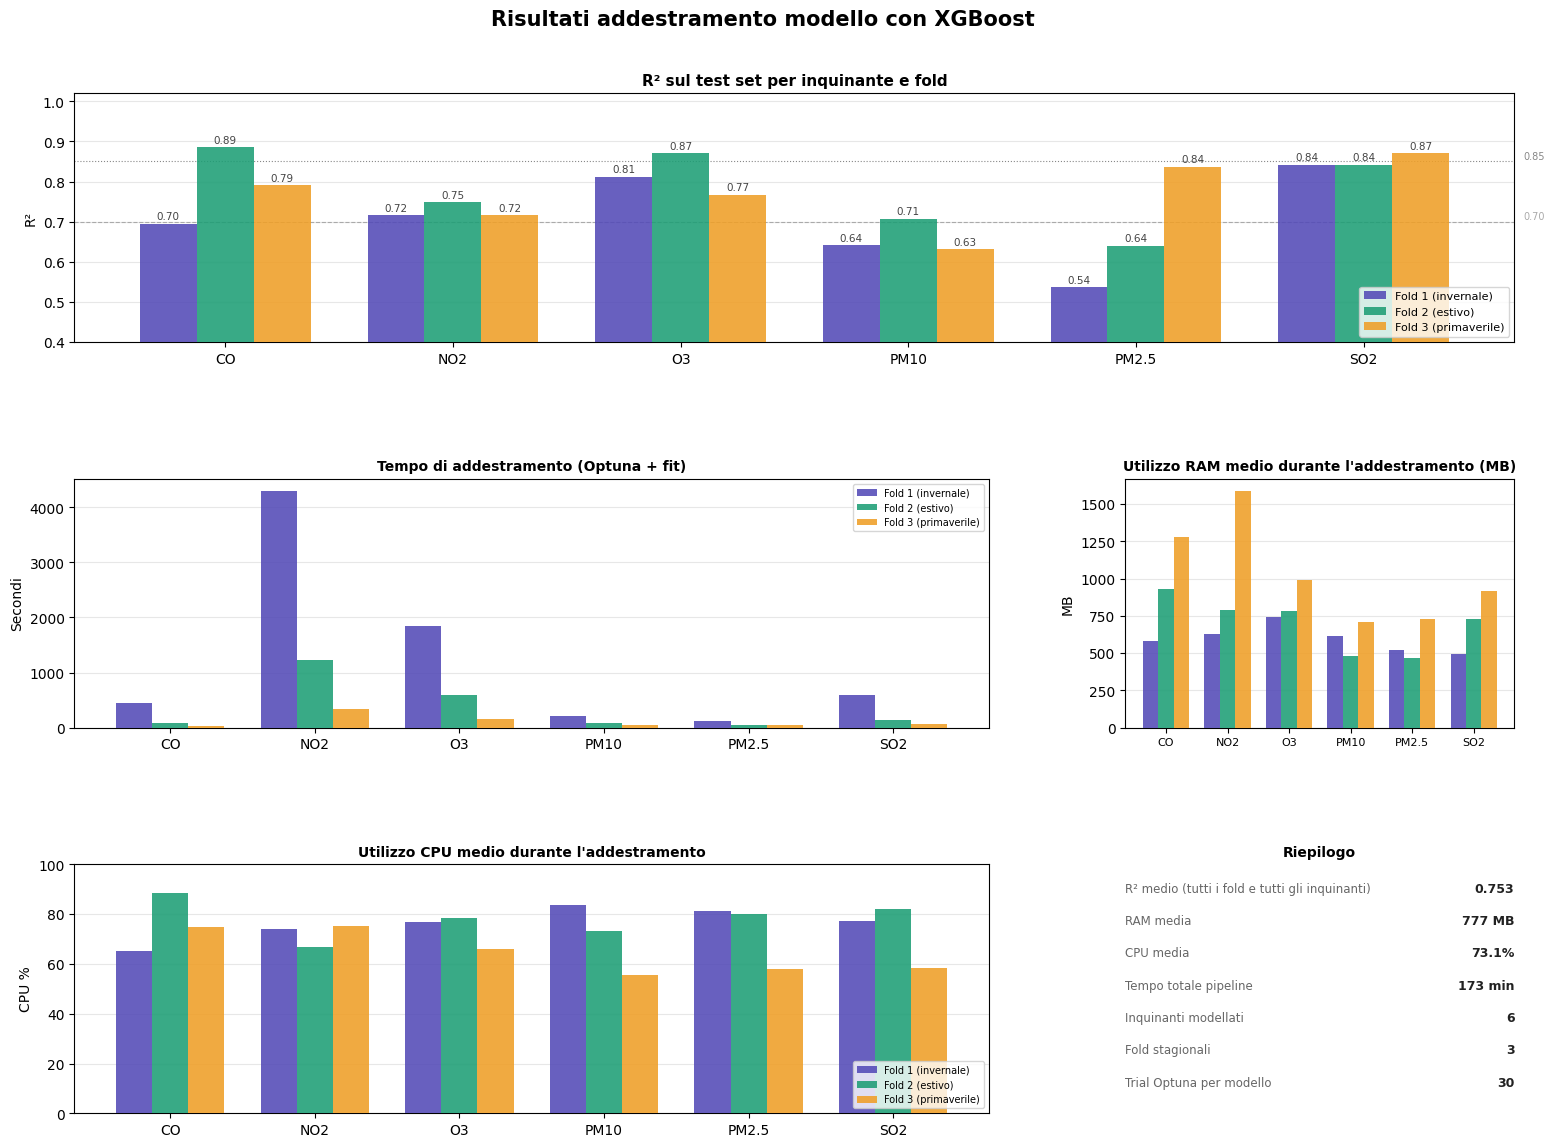

In [21]:

# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("XGBoost_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con XGBoost", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Secondi")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("XGBoost_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Addestramento LightGBM

In [ ]:
# ─────────────────────────────────────────────
# LOOP FOLD × INQUINANTE
# ─────────────────────────────────────────────
N_TRIALS = 30
 
all_summary = []
all_results = []
 
for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")
 
    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]
 
    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")
 
        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])
 
        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]
 
        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue
 
        train, val, test = add_lag_features(train, val, test)
 
        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)
 
        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))
 
        def inverse_y(y):
            return np.expm1(y)
 
        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]
 
        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))
 
        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")
 
        # ── Optuna ───────────────────────────
        def objective(trial):
            params = {
                "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
                "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth":         trial.suggest_int("max_depth", 3, 8),
                "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
                "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
                "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": 42,
                "n_jobs": -1,
                "verbose": -1,
            }
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(period=-1),
                ]
            )
            return mean_squared_error(y_val, m.predict(X_val)) ** 0.5
 
        # ── Optuna + fit finale con monitoraggio ──
        monitor = ResourceMonitor().start()
 
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")
 
        model = lgb.LGBMRegressor(
            **best,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=-1),
            ]
        )
 
        monitor.stop()
 
        print(f"  Best iteration: {model.best_iteration_}")
        monitor.report()
 
        # ── Metriche ─────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true
 
        metrics("Train", X_train, y_train)
        pred_v, true_v = metrics("Val",  X_val,  y_val)
        pred_t, true_t = metrics("Test", X_test, y_test)
 
        fi   = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")
 
        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)
 
        all_summary.append({
            "fold":          fold["name"],
            "pollutant":     pollutant,
            "n_train":       len(X_train),
            "n_val":         len(X_val),
            "n_test":        len(X_test),
            "best_iter":     model.best_iteration_,
            "test_mae":      mean_absolute_error(true_t, pred_t),
            "test_rmse":     np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":       r2_score(true_t, pred_t),
            "top3_feat":     top3,
            "train_time_s":  round(monitor.elapsed_s, 1),
            "ram_delta_mb":  round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":   round(monitor.ram_mean_mb, 1),
            "cpu_pct":       round(monitor.cpu_pct, 1),
            "best_params":   str(best),
        })
 
# ─────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold","pollutant","n_train","n_test",
               "test_mae","test_rmse","test_r2",
               "train_time_s","ram_mean_mb","cpu_pct"]].to_string(index=False))
 
summary.to_csv("LGBM_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Migliori iperparametri: {'n_estimators': 799, 'learning_rate': 0.0423747348183252, 'max_depth': 8, 'num_leaves': 94, 'subsample': 0.8975579024756537, 'colsample_bytree': 0.791844885719143, 'min_child_samples': 75, 'reg_alpha': 0.02038349564476067, 'reg_lambda': 0.01053683991540372}
  Best iteration: 295
  Tempo di addestramento + fine tuning          : 305.7s
  RAM media utilizzata                          : 881 MB
  CPU utilizzata                                : 62.2%
  Train  → MAE=49.478  RMSE=96.806  R²=0.8986
  Val    → MAE=66.139  RMSE=123.058  R²=0.8106
  Test   → MAE=120.967  RMSE=207.528  

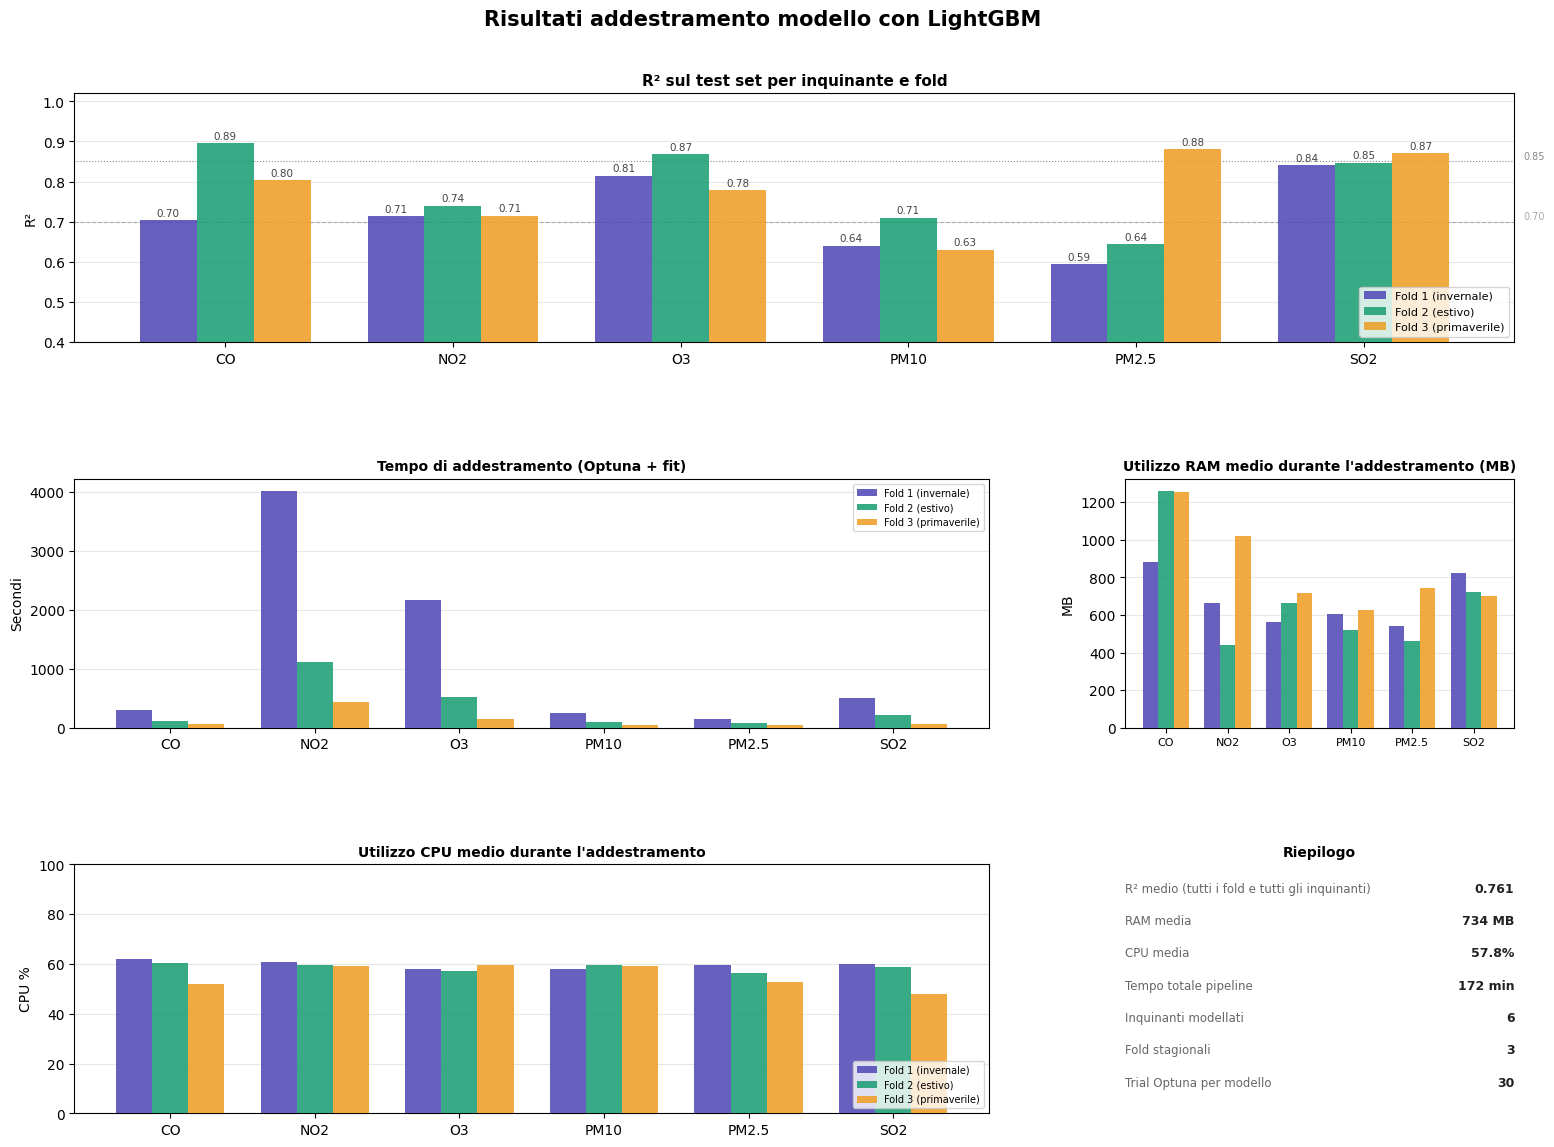

In [23]:

# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("LGBM_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con LightGBM", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Secondi")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("LGBM_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Addestramento SGDRegressor

In [10]:
# ─────────────────────────────────────────────
# DIPENDENZE
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────────
# FOLD × INQUINANTE
# ─────────────────────────────────────────────
FOLDS = [
    {
        "name":         "Fold 1 — test invernale (nov–dic)",
        "cutoff_train": pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":   pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":     pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":         "Fold 2 — test estivo (giu–lug)",
        "cutoff_train": pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":   pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":     pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":         "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train": pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":   pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":     pd.Timestamp("2025-05-31 23:59:59"),
    },
]

# ─────────────────────────────────────────────
# LOOP FOLD × INQUINANTE
# ─────────────────────────────────────────────
N_TRIALS = 30

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        # ── Clip + trasformazione log ─────────
        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            return np.expm1(y)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # ── Scaling (fittato solo su train) ───
        scaler      = StandardScaler().fit(X_train)
        X_train_sc  = scaler.transform(X_train)
        X_val_sc    = scaler.transform(X_val)
        X_test_sc   = scaler.transform(X_test)

        y_train_arr = np.array(y_train)
        y_val_arr   = np.array(y_val)
        y_test_arr  = np.array(y_test)

        # ── Optuna ───────────────────────────
        def objective(trial):
            lr_schedule = trial.suggest_categorical(
                "learning_rate", ["invscaling", "adaptive"]
            )
            params = {
                "alpha":         trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
                "epsilon":       trial.suggest_float("epsilon", 1e-3, 0.5, log=True),
                "eta0":          trial.suggest_float("eta0", 1e-5, 1e-2, log=True),
                "learning_rate": lr_schedule,
                "power_t":       trial.suggest_float("power_t", 0.1, 0.5),
            }
            m = SGDRegressor(
                loss="epsilon_insensitive",
                penalty="l2",
                max_iter=1000,
                tol=1e-4,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                random_state=42,
                **params,
            )
            m.fit(X_train_sc, y_train_arr)
            return mean_squared_error(y_val_arr, m.predict(X_val_sc)) ** 0.5

        # ── Ottimizzazione + fit finale ───────
        monitor = ResourceMonitor().start()

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")

        model = SGDRegressor(
            loss="epsilon_insensitive",
            penalty="l2",
            max_iter=1000,
            tol=1e-4,
            early_stopping=True,
            n_iter_no_change=10,
            validation_fraction=0.1,
            random_state=42,
            alpha=best["alpha"],
            epsilon=best["epsilon"],
            eta0=best["eta0"],
            learning_rate=best["learning_rate"],
            power_t=best["power_t"],
        )
        model.fit(X_train_sc, y_train_arr)

        monitor.stop()
        monitor.report()

        # ── Metriche ─────────────────────────
        def metrics(name, X_sc, y_log):
            pred = inverse_y(model.predict(X_sc))
            true = inverse_y(y_log)
            # clip predizioni negative (possibili con modello lineare)
            pred = np.clip(pred, 0, None)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_train_sc, y_train_arr)
        pred_v, true_v = metrics("Val",  X_val_sc,  y_val_arr)
        pred_t, true_t = metrics("Test", X_test_sc, y_test_arr)

        # ── Feature importance (|coef| × scale) ──
        importances = pd.Series(
            np.abs(model.coef_) * scaler.scale_,
            index=FEATURES,
        ).sort_values(ascending=False)
        top3 = ", ".join(importances.head(3).index.tolist())
        print(f"  Top features: {top3}")

        out = pd.DataFrame(X_test_sc, columns=FEATURES).copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":         fold["name"],
            "pollutant":    pollutant,
            "n_train":      len(X_train),
            "n_val":        len(X_val),
            "n_test":       len(X_test),
            "test_mae":     mean_absolute_error(true_t, pred_t),
            "test_rmse":    np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":      r2_score(true_t, pred_t),
            "top3_feat":    top3,
            "train_time_s": round(monitor.elapsed_s, 1),
            "ram_delta_mb": round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":  round(monitor.ram_mean_mb, 1),
            "cpu_pct":      round(monitor.cpu_pct, 1),
            "best_params":  str(best),
        })

# ─────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold","pollutant","n_train","n_test",
               "test_mae","test_rmse","test_r2",
               "train_time_s","ram_mean_mb","cpu_pct"]].to_string(index=False))

summary.to_csv("SGD_SVM_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Migliori iperparametri: {'learning_rate': 'invscaling', 'alpha': 0.004328075459393268, 'epsilon': 0.10283945612253492, 'eta0': 3.249036527542622e-05, 'power_t': 0.3092012106595908}
  Tempo di addestramento + fine tuning          : 786.2s
  RAM media utilizzata                          : 678 MB
  CPU utilizzata                                : 11.7%
  Train  → MAE=5355280606611.369  RMSE=484403955266263.750  R²=-2539524356013801313665024.0000
  Val    → MAE=31016199.355  RMSE=4982237145.418  R²=-310492210184069.6875
  Test   → MAE=2995.035  RMSE=545303.704  R²=-2041438.0028
  Top features: lag_1h, la

In [12]:

# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("SGD_SVM_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con LightGBM", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Secondi")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("LSVM_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: typing.SupportsInt, height: typing.SupportsInt, dpi: typing.SupportsFloat)

Invoked with: 1554, 293261209390612, 100.0

<Figure size 1600x1200 with 5 Axes>

# Addestramento Random Forest

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURAZIONE
# ─────────────────────────────────────────────────────────────────

N_TRIALS = 30           # uguale a XGBoost/LGBM per confronto equo

# 50 alberi per optuna
OPTUNA_N_TREES = 50

# Nel fit finale: range per n_estimators (ottimizzato come secondo stage
# o fissato — vedi nota sotto).
FINAL_N_TREES_RANGE = (200, 500)   # (min, max) per il secondo stage Optuna
                                    # oppure imposta FINAL_N_TREES a un
                                    # valore fisso se vuoi saltare il 2° stage
FINAL_N_TREES = 300    # usato se SKIP_TREES_STAGE = True
SKIP_TREES_STAGE = True  # True → fit finale con FINAL_N_TREES fisso (più veloce)
                          # False → secondo stage Optuna solo su n_estimators

RANDOM_STATE = 42

# ─────────────────────────────────────────────────────────────────
# LOOP  FOLD × INQUINANTE
# ─────────────────────────────────────────────────────────────────

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            return np.expm1(y)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # Converti in array numpy una volta sola (risparmia overhead pandas)
        X_tr_np  = X_train.values
        y_tr_np  = y_train.values
        X_val_np = X_val.values
        y_val_np = y_val.values

        print(f"  Optuna: {N_TRIALS} trial × {OPTUNA_N_TREES} alberi su "
              f"TUTTE le {len(X_train):,} righe del train")

        # ── Stage 1 Optuna: iperparametri strutturali ───────────────
        # n_estimators è fissato a OPTUNA_N_TREES → costo per trial
        # contenuto pur usando tutte le righe (confronto equo con XGB).
        def objective(trial):
            params = {
                "n_estimators":      OPTUNA_N_TREES,   # fisso durante la ricerca
                "max_depth":         trial.suggest_int("max_depth", 8, 30),
                "max_features":      trial.suggest_categorical(
                                         "max_features",
                                         ["sqrt", "log2", 0.3, 0.5]),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 50),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "bootstrap":         trial.suggest_categorical(
                                         "bootstrap", [True, False]),
                "n_jobs":       -1,
                "random_state": RANDOM_STATE,
            }
            m = RandomForestRegressor(**params)
            m.fit(X_tr_np, y_tr_np)
            return mean_squared_error(y_val_np, m.predict(X_val_np)) ** 0.5

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

        best = study.best_params
        best.pop("n_estimators", None)   # verrà impostato nel fit finale

        # ── Stage 2 (opzionale): ottimizza n_estimators ────────────
        if not SKIP_TREES_STAGE:
            def objective_trees(trial):
                n_est = trial.suggest_int("n_estimators",
                                          *FINAL_N_TREES_RANGE)
                m = RandomForestRegressor(
                    **best, n_estimators=n_est,
                    n_jobs=-1, random_state=RANDOM_STATE,
                )
                m.fit(X_tr_np, y_tr_np)
                return mean_squared_error(y_val_np, m.predict(X_val_np)) ** 0.5

            study2 = optuna.create_study(direction="minimize")
            study2.optimize(objective_trees, n_trials=8, show_progress_bar=False)
            final_n_trees = study2.best_params["n_estimators"]
            print(f"  Stage 2 → n_estimators ottimale: {final_n_trees}")
        else:
            final_n_trees = FINAL_N_TREES

        best["n_estimators"] = final_n_trees
        print(f"  Migliori iperparametri: {best}")

        # ── Fit finale sull'intero train set ───────────────────────
        monitor = ResourceMonitor().start()

        model = RandomForestRegressor(
            **best,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
        model.fit(X_tr_np, y_tr_np)

        monitor.stop()

        print(f"  Numero alberi effettivi: {model.n_estimators}")
        monitor.report()

        # ── Metriche ───────────────────────────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_tr_np, y_tr_np)
        pred_v, true_v = metrics("Val",   X_val_np, y_val_np)
        pred_t, true_t = metrics("Test",  X_test.values, y_test.values)

        # Feature importance (impurity-based, come in LightGBM)
        fi   = pd.Series(model.feature_importances_,
                         index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")

        # ── Salvataggio risultati ───────────────────────────────────
        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":          fold["name"],
            "pollutant":     pollutant,
            "n_train":       len(X_train),
            "n_val":         len(X_val),
            "n_test":        len(X_test),
            "n_estimators":  model.n_estimators,
            "test_mae":      mean_absolute_error(true_t, pred_t),
            "test_rmse":     np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":       r2_score(true_t, pred_t),
            "top3_feat":     top3,
            "train_time_s":  round(monitor.elapsed_s, 1),
            "ram_delta_mb":  round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":   round(monitor.ram_mean_mb, 1),
            "cpu_pct":       round(monitor.cpu_pct, 1),
            "best_params":   str(best),
        })

# ─────────────────────────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold", "pollutant", "n_train", "n_test",
               "test_mae", "test_rmse", "test_r2",
               "train_time_s", "ram_mean_mb", "cpu_pct"]].to_string(index=False))

summary.to_csv("RF_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Optuna: 30 trial × 50 alberi su TUTTE le 429,149 righe del train
  Migliori iperparametri: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 7, 'min_samples_split': 7, 'bootstrap': False, 'n_estimators': 300}
  Numero alberi effettivi: 300
  Tempo di addestramento + fine tuning          : 216.4s
  RAM media utilizzata                          : 745 MB
  CPU utilizzata                                : 92.2%
  Train  → MAE=34.849  RMSE=72.613  R²=0.9429
  Val    → MAE=65.873  RMSE=123.810  R²=0.8083
  Test   → MAE=121.520  RMSE=209.246  R²=0.6994
  Top features: lag_1h, lag_2h, roll_mean_6h



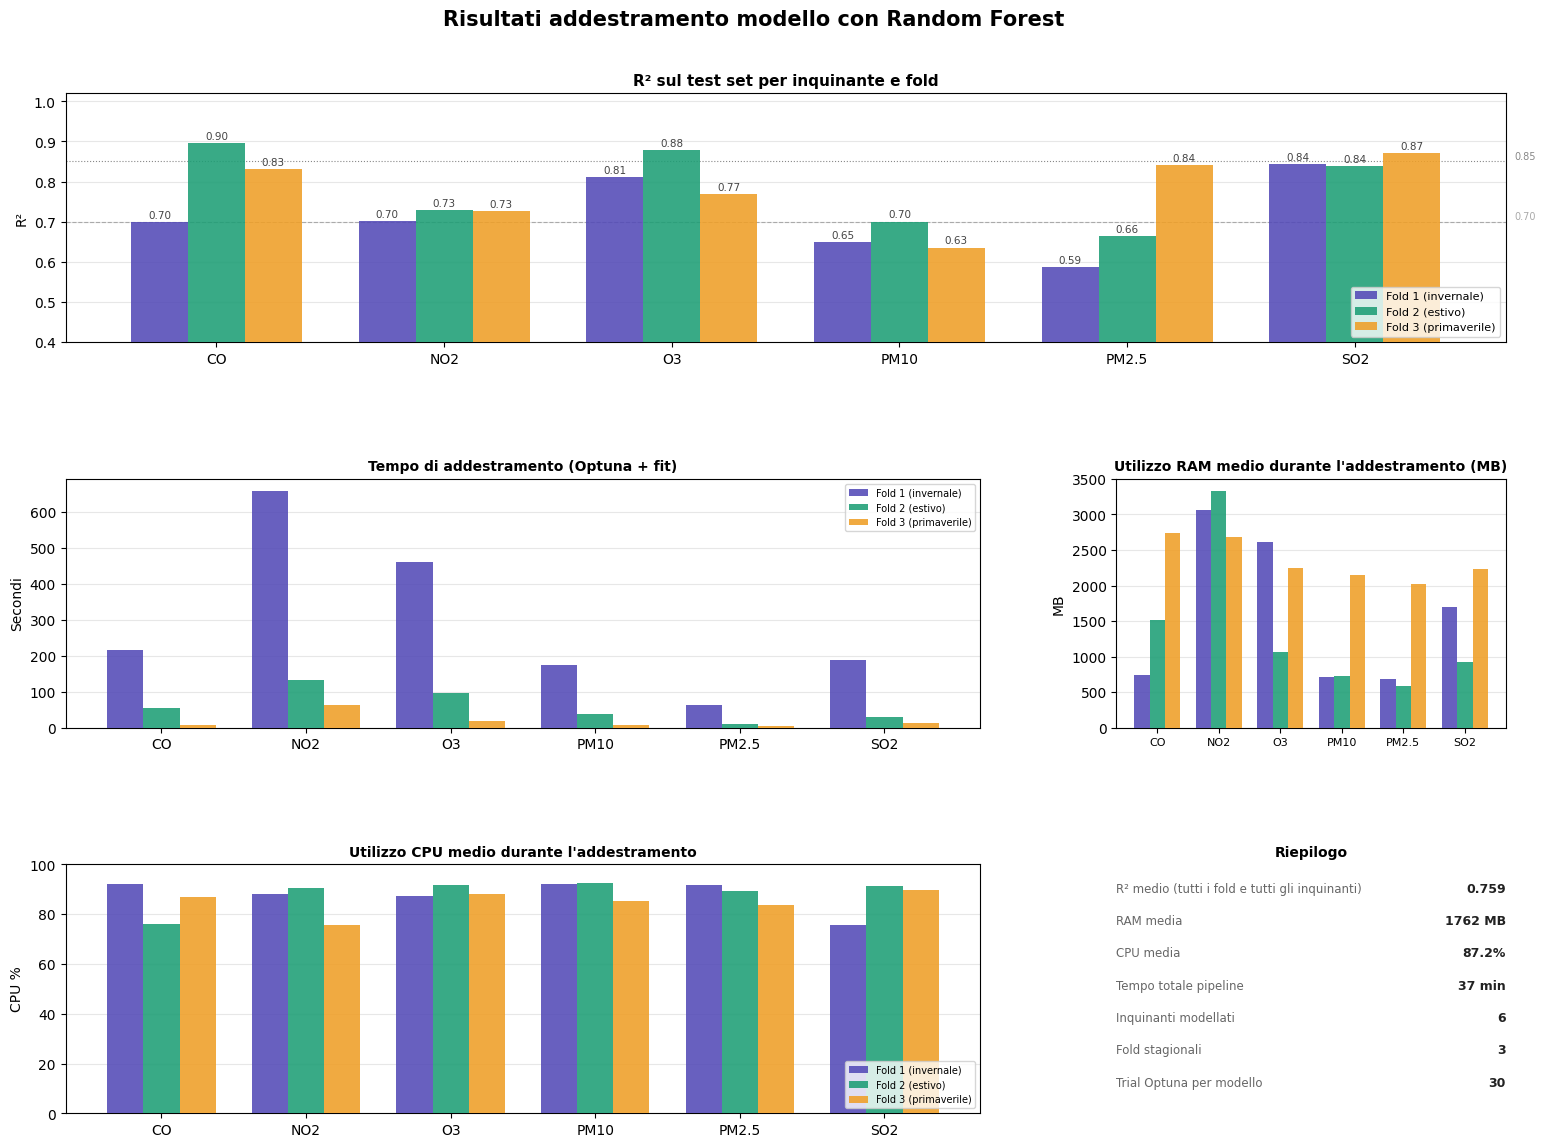

In [11]:

# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("RF_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con Random Forest", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Secondi")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("RF_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Addestramento Decision Trees

In [20]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURAZIONE
# ─────────────────────────────────────────────────────────────────

N_TRIALS     = 30     # uguale a XGBoost/LGBM/RF per confronto equo
RANDOM_STATE = 42

# ─────────────────────────────────────────────────────────────────
# LOOP  FOLD × INQUINANTE
# ─────────────────────────────────────────────────────────────────

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            return np.expm1(y)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # Converti in array numpy una volta sola
        X_tr_np  = X_train.values
        y_tr_np  = y_train.values
        X_val_np = X_val.values
        y_val_np = y_val.values

        print(f"  Optuna: {N_TRIALS} trial su TUTTE le {len(X_train):,} righe del train")

        # ── Optuna ─────────────────────────────────────────────────
        # DT è veloce anche su 5M righe → nessun sottoinsieme necessario.
        # Lo spazio degli iperparametri è lo stesso di RF (meno bootstrap/
        # max_features che qui hanno ruolo diverso) più criterion e splitter.
        def objective(trial):
            params = {
                "max_depth":         trial.suggest_int("max_depth", 3, 30),
                "max_features":      trial.suggest_categorical(
                                         "max_features",
                                         ["sqrt", "log2", None, 0.3, 0.5]),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 100),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
                "criterion":         trial.suggest_categorical(
                                         "criterion",
                                         ["squared_error", "friedman_mse"]),
                "splitter":          trial.suggest_categorical(
                                         "splitter", ["best", "random"]),
                "random_state": RANDOM_STATE,
            }
            m = DecisionTreeRegressor(**params)
            m.fit(X_tr_np, y_tr_np)
            return mean_squared_error(y_val_np, m.predict(X_val_np)) ** 0.5

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")

        # ── Fit finale sull'intero train set ───────────────────────
        monitor = ResourceMonitor().start()

        model = DecisionTreeRegressor(
            **best,
            random_state=RANDOM_STATE,
        )
        model.fit(X_tr_np, y_tr_np)

        monitor.stop()

        print(f"  Profondità effettiva: {model.get_depth()}  "
              f"  N° foglie: {model.get_n_leaves():,}")
        monitor.report()

        # ── Metriche ───────────────────────────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_tr_np, y_tr_np)
        pred_v, true_v = metrics("Val",   X_val_np, y_val_np)
        pred_t, true_t = metrics("Test",  X_test.values, y_test.values)

        # Feature importance (impurity-based)
        fi   = pd.Series(model.feature_importances_,
                         index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")

        # ── Salvataggio risultati ───────────────────────────────────
        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":          fold["name"],
            "pollutant":     pollutant,
            "n_train":       len(X_train),
            "n_val":         len(X_val),
            "n_test":        len(X_test),
            "tree_depth":    model.get_depth(),
            "n_leaves":      model.get_n_leaves(),
            "test_mae":      mean_absolute_error(true_t, pred_t),
            "test_rmse":     np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":       r2_score(true_t, pred_t),
            "top3_feat":     top3,
            "train_time_s":  round(monitor.elapsed_s, 1),
            "ram_delta_mb":  round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":   round(monitor.ram_mean_mb, 1),
            "cpu_pct":       round(monitor.cpu_pct, 1),
            "best_params":   str(best),
        })

# ─────────────────────────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold", "pollutant", "n_train", "n_test",
               "test_mae", "test_rmse", "test_r2",
               "tree_depth", "n_leaves",
               "train_time_s", "ram_mean_mb", "cpu_pct"]].to_string(index=False))

summary.to_csv("DT_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Optuna: 30 trial su TUTTE le 429,149 righe del train
  Migliori iperparametri: {'max_depth': 11, 'max_features': None, 'min_samples_leaf': 80, 'min_samples_split': 2, 'criterion': 'friedman_mse', 'splitter': 'best'}
  Profondità effettiva: 11    N° foglie: 737
  Tempo di addestramento + fine tuning          : 3.7s
  RAM media utilizzata                          : 1607 MB
  CPU utilizzata                                : 10.8%
  Train  → MAE=53.133  RMSE=105.747  R²=0.8790
  Val    → MAE=70.141  RMSE=130.304  R²=0.7876
  Test   → MAE=130.753  RMSE=223.855  R²=0.6560
  Top features: lag_1h, roll_mean_

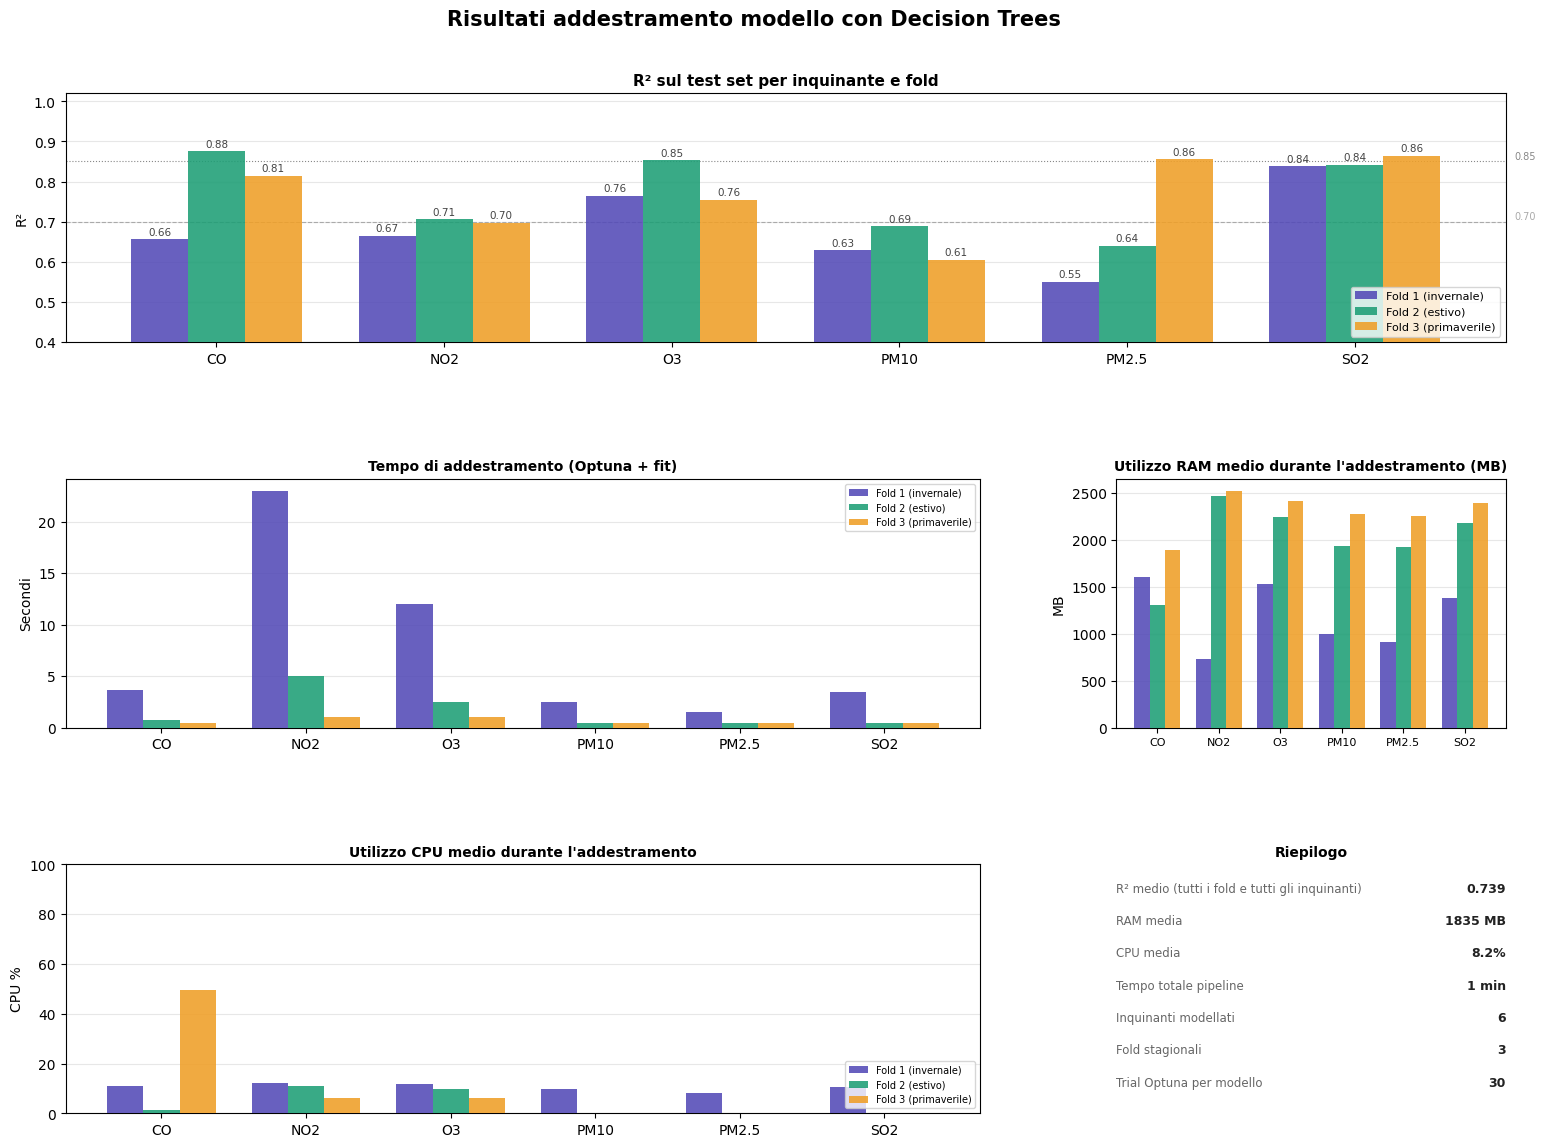

In [21]:

# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("DT_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con Decision Trees", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Secondi")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("DT_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Riassunto risultati

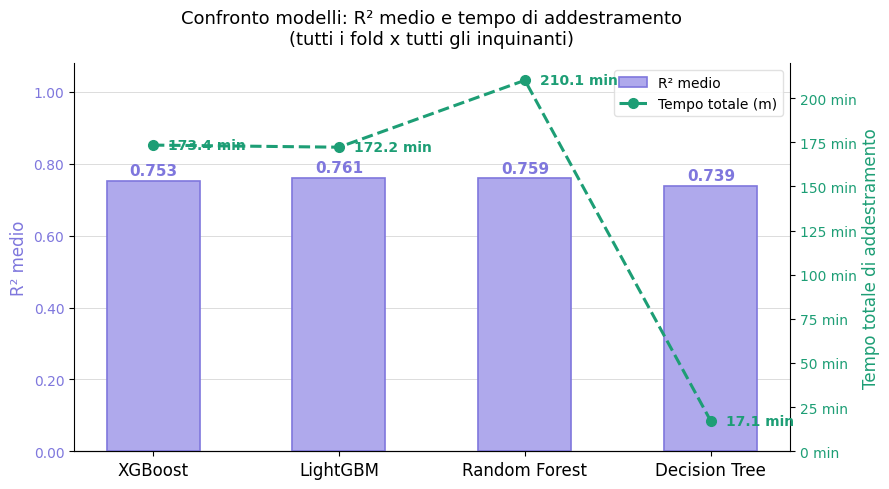

In [28]:
# ─────────────────────────────────────────────────────────────────
# CARICAMENTO DATI
# ─────────────────────────────────────────────────────────────────

summaries = {
    "XGBoost":        pd.read_csv("XGBoost_summary.csv"),
    "LightGBM":       pd.read_csv("LGBM_summary.csv"),
    "Random Forest":  pd.read_csv("RF_summary.csv"),
    "Decision Tree":  pd.read_csv("DT_summary.csv"),
}

models      = list(summaries.keys())
r2_means    = [summaries[m]["test_r2"].mean()       for m in models]
time_totals = [173.4, 172.2, 210.1, 17.1]

# ─────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────

BAR_COLOR  = "#AFA9EC"   # purple 200
BAR_EDGE   = "#7F77DD"   # purple 400
LINE_COLOR = "#1D9E75"   # teal 400

# ─────────────────────────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

x = np.arange(len(models))
bar_width = 0.5

# ── Barre R² (asse sinistro) ──────────────────────────────────────
bars = ax1.bar(
    x, r2_means,
    width=bar_width,
    color=BAR_COLOR,
    edgecolor=BAR_EDGE,
    linewidth=1.2,
    zorder=3,
    label="R² medio",
)

# Etichetta valore sopra ogni barra
for bar, val in zip(bars, r2_means):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{val:.3f}",
        ha="center", va="bottom",
        fontsize=11, color=BAR_EDGE, fontweight="bold",
    )

ax1.set_ylim(0, 1.08)
ax1.set_ylabel("R² medio", color=BAR_EDGE, fontsize=12)
ax1.tick_params(axis="y", labelcolor=BAR_EDGE)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=12)
ax1.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
ax1.spines[["top", "right"]].set_visible(False)

# ── Linea tempo (asse destro) ─────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(
    x, time_totals,
    color=LINE_COLOR,
    linewidth=2.2,
    linestyle="--",
    marker="o",
    markersize=7,
    zorder=4,
    label="Tempo totale (m)",
)

# Etichetta valore accanto ad ogni punto (formattato in minuti se >= 60s)
for xi, val in zip(x, time_totals):
    label = f"{val:.1f} min"
    ax2.text(
        xi + 0.08, val,
        label,
        ha="left", va="center",
        fontsize=10, color=LINE_COLOR, fontweight="bold",
    )

ax2.set_ylabel("Tempo totale di addestramento", color=LINE_COLOR, fontsize=12)
ax2.tick_params(axis="y", labelcolor=LINE_COLOR)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, _: f"{v:.0f} min"
    )
)
ax2.set_ylim(bottom=0)
ax2.spines[["top", "left"]].set_visible(False)

# ── Legenda unificata ─────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    fontsize=10,
    framealpha=0.85,
    edgecolor="gainsboro",
)

plt.title(
    "Confronto modelli: R² medio e tempo di addestramento\n"
    "(tutti i fold x tutti gli inquinanti)",
    fontsize=13,
    pad=14,
)
plt.tight_layout()
plt.show()
#plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")